In [1]:
#--- prediction of month 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import joblib


In [22]:
df = pd.read_csv(r'C:\Users\User\dev\training_model\dataset\modified_financial_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.rename(columns={"^GSPC": "SPX", "EURUSD=X": "EUR/USD"}, inplace=True)

In [23]:
features = ['SPX', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'

df.dropna(inplace=True)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

In [24]:
n_steps = 30

def create_lstm_windows(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(X)):
        X_seq.append(X[i - n_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

In [25]:
X_seq, y_seq = create_lstm_windows(X_scaled, y_scaled, n_steps=n_steps)

In [26]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_steps, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')

model.fit(X_seq, y_seq, epochs=180, batch_size=32, verbose=0) 

c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
future_predictions = []
last_window = X_scaled[-n_steps:]  

for _ in range(30): 
    input_seq = last_window.reshape(1, n_steps, X_seq.shape[2])
    pred = model.predict(input_seq, verbose=0)[0][0]
    future_predictions.append(pred)
    
    next_features = last_window[-1].copy()
    last_window = np.vstack([last_window[1:], next_features])

future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).ravel()

last_date = df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

future_predictions_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_GLD': future_predictions
}).set_index('Date')

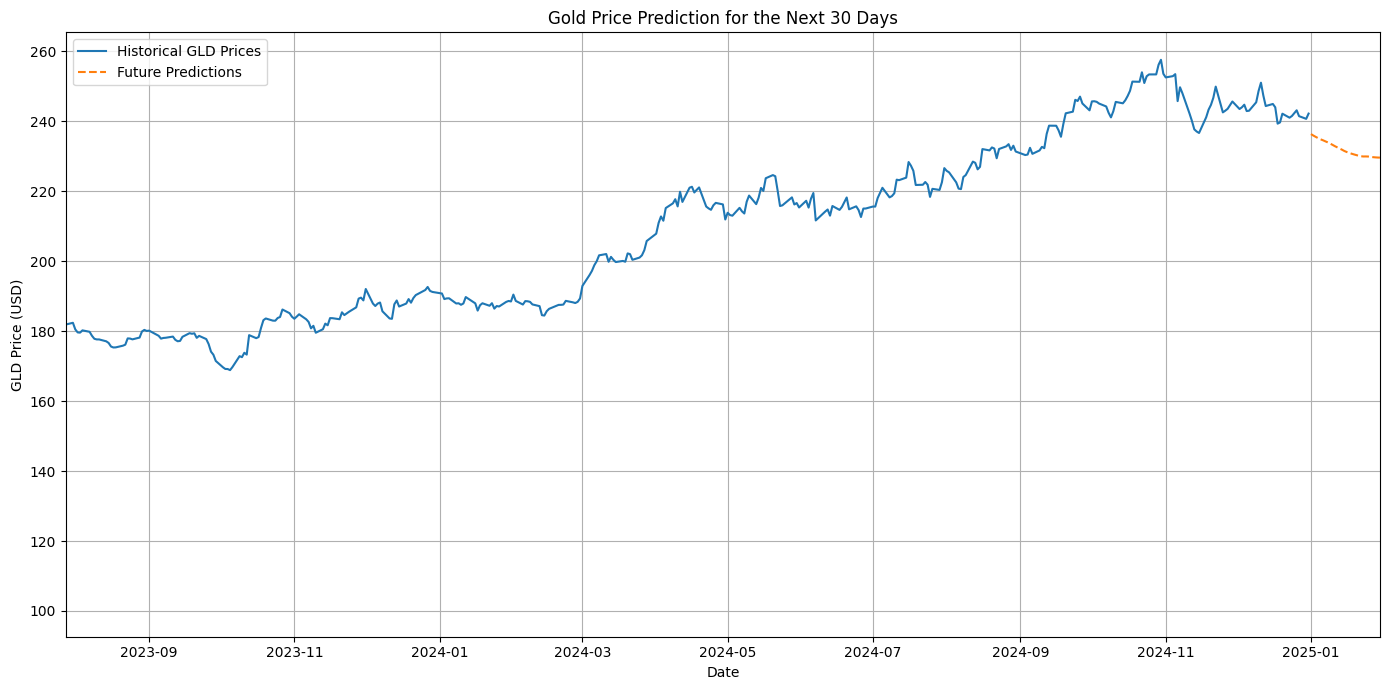

In [28]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['GLD'], label="Historical GLD Prices")
plt.plot(future_predictions_df.index, future_predictions_df['Predicted_GLD'], label="Future Predictions", linestyle='--')
plt.title("Gold Price Prediction for the Next 30 Days")
plt.xlabel("Date")
plt.ylabel("GLD Price (USD)")
plt.xlim(df['Date'].iloc[-360], future_predictions_df.index[-1])
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
path = r'C:\Users\User\dev\training_model\models\last_model.pkl'
joblib.dump(model, path)

['C:\\Users\\User\\dev\\training_model\\models\\last_model.pkl']

In [30]:
path = r'C:\Users\User\dev\training_model\scalers\last_scaler_X.pkl'
joblib.dump(scaler_X, path)

['C:\\Users\\User\\dev\\training_model\\scalers\\last_scaler_X.pkl']

In [31]:
path = r'C:\Users\User\dev\training_model\scalers\last_scaler_y.pkl'
joblib.dump(scaler_y, path)

['C:\\Users\\User\\dev\\training_model\\scalers\\last_scaler_y.pkl']